# Ensemble Learning: Random Forest vs XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

%matplotlib inline

### Load and Clean the Data

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### Split Features and Target

In [3]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train Random Forest

In [4]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.68      0.45      0.54       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



### Train XGBoost

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



### Compare Against Earlier Single Models

In [7]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        0.8041,  # from Task 6
        0.7941,  # from Task 6
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'F1-score (Churn=1)': [
        0.87,  # from Task 6
        0.60,  # from Task 6
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})
comparison

,Model,Accuracy,F1-score (Churn=1)
0,Logistic Regression,0.804100,0.870000
1,Decision Tree,0.794100,0.600000
2,Random Forest,0.797729,0.542536
3,XGBoost,0.787793,0.572246


### Plot Feature Importances — Random Forest

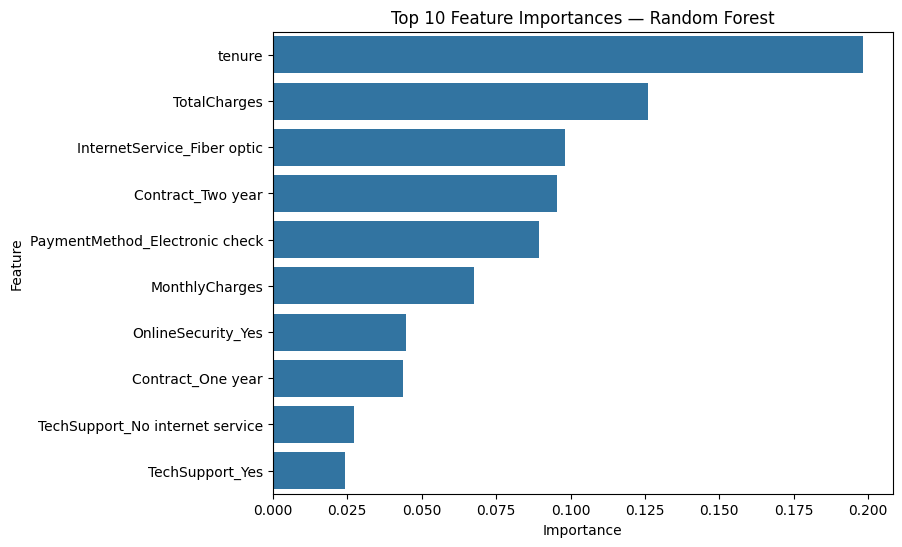

In [8]:
rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=rf_importances)
plt.title('Top 10 Feature Importances — Random Forest')
plt.show()

### Plot Feature Importances — XGBoost

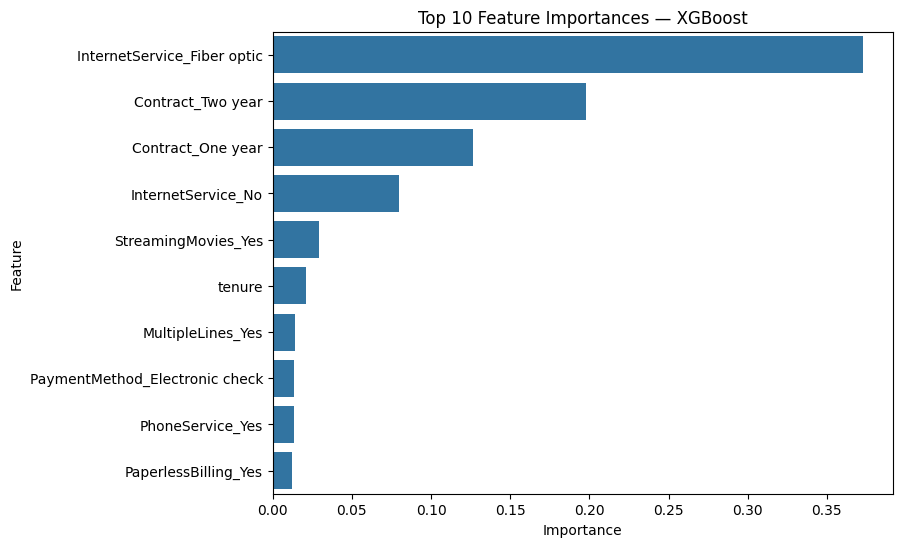

In [9]:
xgb_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=xgb_importances)
plt.title('Top 10 Feature Importances — XGBoost')
plt.show()

## Comparing Feature Importances
Random Forest ranks [tenure] as most important, while XGBoost ranks
[internetService-fiber optic] highest. [Note overlaps or differences actually see —
e.g. "Both agree that Contract type and tenure are top drivers, but
XGBoost weights MonthlyCharges more heavily than Random Forest does."]
This difference likely stems from how each algorithm builds trees — Random
Forest averages many independent trees, while XGBoost builds trees
sequentially, each correcting the previous one's errors, which can shift
which features get emphasized.

## Random Forest vs XGBoost
Random Forest creates many decision trees at the same time using different random data and features.
It combines the results of all the trees to make a final prediction. This helps reduce errors and overfitting.
XGBoost creates trees one after another. Each new tree tries to fix the mistakes made by the previous tree.
XGBoost can often give better accuracy, but it needs more careful tuning to avoid overfitting. Random Forest is usually simpler and easier to use with less tuning.